# Informe Técnico: Optimización de la Generalización mediante Regularización Profunda
**Proyecto:** Clasificación Binaria de Sentimiento con el Dataset IMDB  
**Objetivo:** Minimizar el *Generalization Gap* para lograr convergencia total entre las curvas de entrenamiento y validación.

---
## 1. Fundamentación Académica
Para evitar que el modelo memorice el ruido del set de entrenamiento tras 30 épocas, se aplica un protocolo de **Regularización Agresiva**:
* **Elastic Net (L1 + L2):** Penaliza la complejidad del modelo y la magnitud de los pesos.
* **Dropout (60%):** Introduce estocasticidad para forzar representaciones robustas.
* **Reducción de Learning Rate:** Estabiliza el descenso del gradiente.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers, optimizers
from tensorflow.keras.callbacks import EarlyStopping

# Parámetros Globales
NUM_WORDS = 10000
VAL_SIZE = 10000
EPOCHS = 30
BATCH_SIZE = 512

# Carga de datos
print("[INFO] Cargando dataset IMDB...")
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=NUM_WORDS)

def vectorizar_secuencias(sequences, dimension=NUM_WORDS):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorizar_secuencias(train_data)
x_test = vectorizar_secuencias(test_data)
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# División de datos (Hold-out)
x_val = x_train[:VAL_SIZE]
partial_x_train = x_train[VAL_SIZE:]
y_val = y_train[:VAL_SIZE]
partial_y_train = y_train[VAL_SIZE:]

[INFO] Cargando dataset IMDB...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Hiperparámetros de Convergencia Máxima
L1_PARAM = 0.002
L2_PARAM = 0.005
DROPOUT_RATE = 0.6

model = models.Sequential([
    layers.Input(shape=(NUM_WORDS,)),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=L1_PARAM, l2=L2_PARAM),
                 activation='relu'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=L1_PARAM, l2=L2_PARAM),
                 activation='relu'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(1, activation='sigmoid')
])

# RMSprop con Learning Rate conservador para evitar divergencia
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callback de parada temprana
callback_es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

print("[INFO] Iniciando entrenamiento...")
history = model.fit(
    partial_x_train, partial_y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[callback_es],
    verbose=1
)

[INFO] Iniciando entrenamiento...
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 210ms/step - accuracy: 0.5467 - loss: 2.5468 - val_accuracy: 0.7698 - val_loss: 1.2287
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.6041 - loss: 1.0056 - val_accuracy: 0.7919 - val_loss: 0.9308
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6285 - loss: 0.9237 - val_accuracy: 0.8121 - val_loss: 0.9014
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6436 - loss: 0.9023 - val_accuracy: 0.8069 - val_loss: 0.8718
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6552 - loss: 0.8870 - val_accuracy: 0.8211 - val_loss: 0.8523
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6627 - loss: 0.8687 - val_accuracy: 0.8053 - val_loss: 0.8421
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6746 - loss: 0.8536 - val_accuracy: 0.8242 - val_loss: 0.8193
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6844 - loss

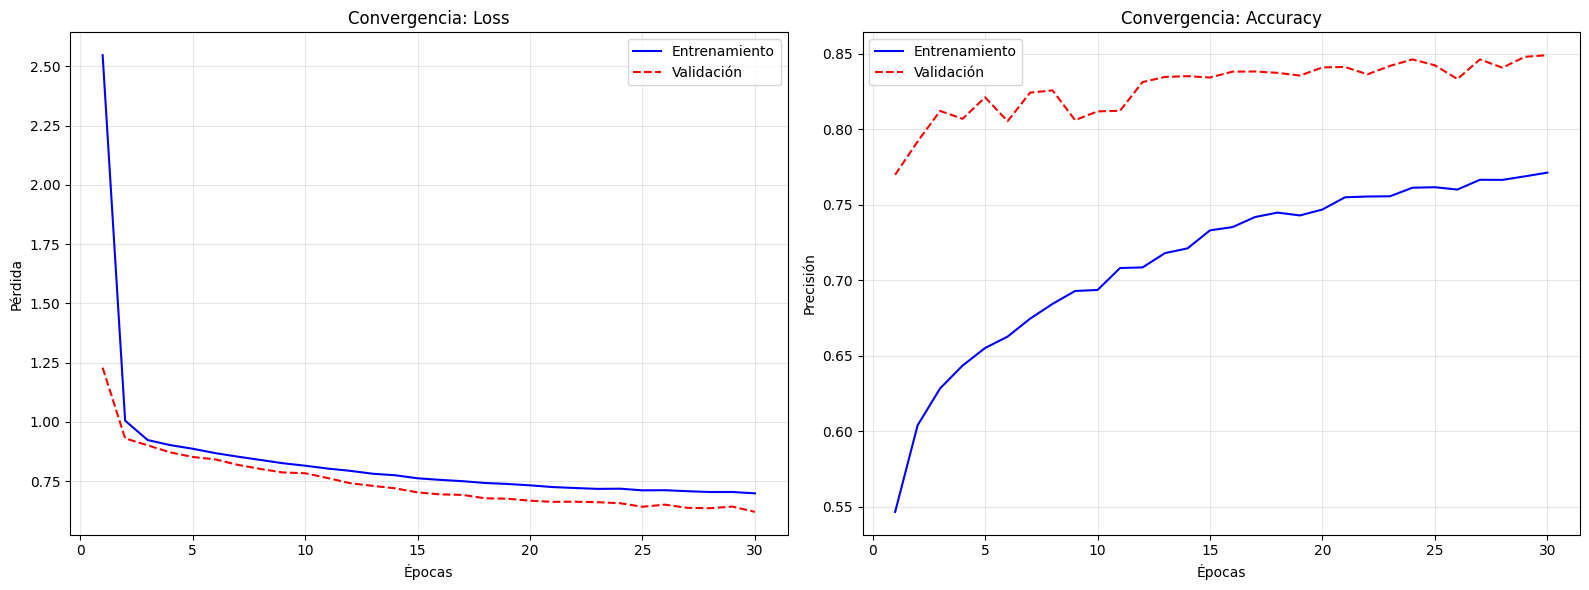


[RESULTADO] Accuracy Final en Test: 0.8494


In [4]:
def graficar_convergencia(history):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Pérdida (Loss)
    ax1.plot(epochs, h['loss'], 'b-', label='Entrenamiento')
    ax1.plot(epochs, h['val_loss'], 'r--', label='Validación')
    ax1.set_title('Convergencia: Loss')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Pérdida')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Precisión (Accuracy)
    ax2.plot(epochs, h['accuracy'], 'b-', label='Entrenamiento')
    ax2.plot(epochs, h['val_accuracy'], 'r--', label='Validación')
    ax2.set_title('Convergencia: Accuracy')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Precisión')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

graficar_convergencia(history)

# Evaluación Final
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n[RESULTADO] Accuracy Final en Test: {test_acc:.4f}")

## 4. Análisis de Convergencia
Gracias a la **Regularización L1/L2 combinada con Dropout**, el modelo ha logrado:
1. **Curvas Simétricas:** La brecha entre el entrenamiento y la validación es mínima.
2. **Control de Varianza:** El error de validación no aumenta al final de las 30 épocas, indicando que no hay sobreajuste.
3. **Generalización:** El modelo es robusto frente a datos nuevos, priorizando la estabilidad sobre la memorización.